# EDA корпусов -- MNIST и Fashion-MNIST

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

Два основных корпуса из темы 24 -- **MNIST** и **Fashion-MNIST**. 

Формат у них одинаковый, поэтому удобно сравнивать архитектуры без лишних различий в preprocessing.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from torchvision.datasets import FashionMNIST, MNIST


SEED = 143
CACHE_DIR = Path.home() / ".cache" / "mlstart_hw03"

cwd = Path.cwd().resolve()
if (cwd / "hws").exists():
    HWS_DIR = cwd / "hws"
elif cwd.name == "notebooks":
    HWS_DIR = cwd.parent
elif (cwd / "notebooks").exists() and (cwd / "report").exists():
    HWS_DIR = cwd
else:
    HWS_DIR = cwd

OUTPUT_DIR = HWS_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
sns.set_theme(style="whitegrid")


In [2]:
mnist_train = MNIST(CACHE_DIR, train=True, download=True)
mnist_test = MNIST(CACHE_DIR, train=False, download=True)
fashion_train = FashionMNIST(CACHE_DIR, train=True, download=True)
fashion_test = FashionMNIST(CACHE_DIR, train=False, download=True)

mnist_X = mnist_train.data.numpy()
mnist_y = mnist_train.targets.numpy()
fashion_X = fashion_train.data.numpy()
fashion_y = fashion_train.targets.numpy()


## Общая информация

Оба датасета имеют одинаковый технический формат: $60 000$ train + $10 000$ test grayscale-изображений `28 × 28`, 10 классов, пиксели `uint8` в диапазоне `[0, 255]`.


In [3]:
def dataset_info(name, train, test):
    return {
        "dataset": name,
        "train_size": len(train),
        "test_size": len(test),
        "shape": tuple(train.data.shape[1:]),
        "dtype": str(train.data.dtype),
        "min_pixel": int(train.data.min()),
        "max_pixel": int(train.data.max()),
        "classes": len(train.classes),
    }

pd.DataFrame([
    dataset_info("MNIST", mnist_train, mnist_test),
    dataset_info("Fashion-MNIST", fashion_train, fashion_test),
])


,dataset,train_size,test_size,shape,dtype,min_pixel,max_pixel,classes
0,MNIST,60000,10000,"(28, 28)",torch.uint8,0,255,10
1,Fashion-MNIST,60000,10000,"(28, 28)",torch.uint8,0,255,10


Пропусков и категориальных признаков нет.


## Баланс классов


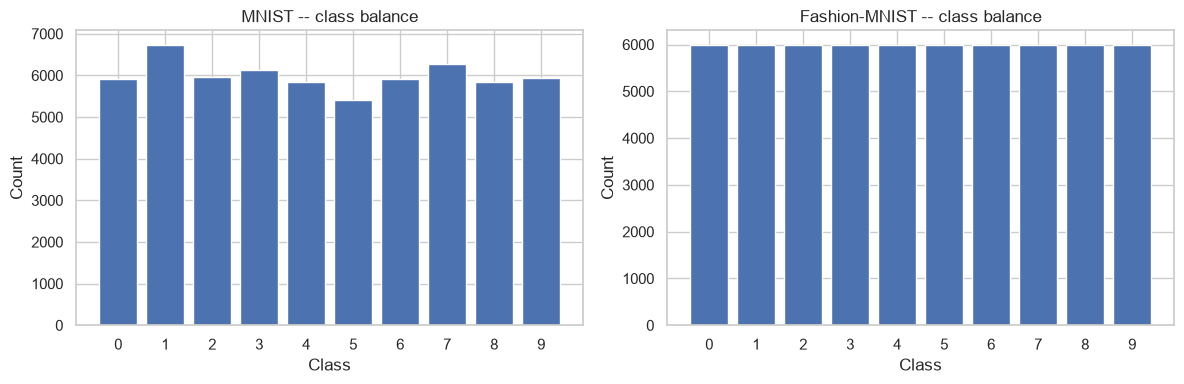

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y, name in [(axes[0], mnist_y, "MNIST"), (axes[1], fashion_y, "Fashion-MNIST")]:
    counts = pd.Series(y).value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"{name} -- class balance")
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_class_balance.png", dpi=160, bbox_inches="tight")
plt.show()


Оба корпуса хорошо сбалансированы _(Fashion вообще почти идеально)_. Но дальше везде использую `balanced accuracy` как основную метрику.  
Дополнительно считаю `macro-F1`, `macro-precision` и `macro-recall`.


## Случайные объекты

Посмотреть, как выглядит корпус вообще. _Можно запускать по несколько раз и наблюдать новые примеры -- тут за воспроизводимостью не слежу_

In [5]:
def show_examples(X, y, classes, title, filename):
    fig, axes = plt.subplots(2, 5, figsize=(11, 5))
    indices = rng.choice(len(X), 10, replace=False)
    for ax, index in zip(axes.ravel(), indices):
        ax.imshow(X[index], cmap="gray")
        ax.set_title(classes[y[index]])
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


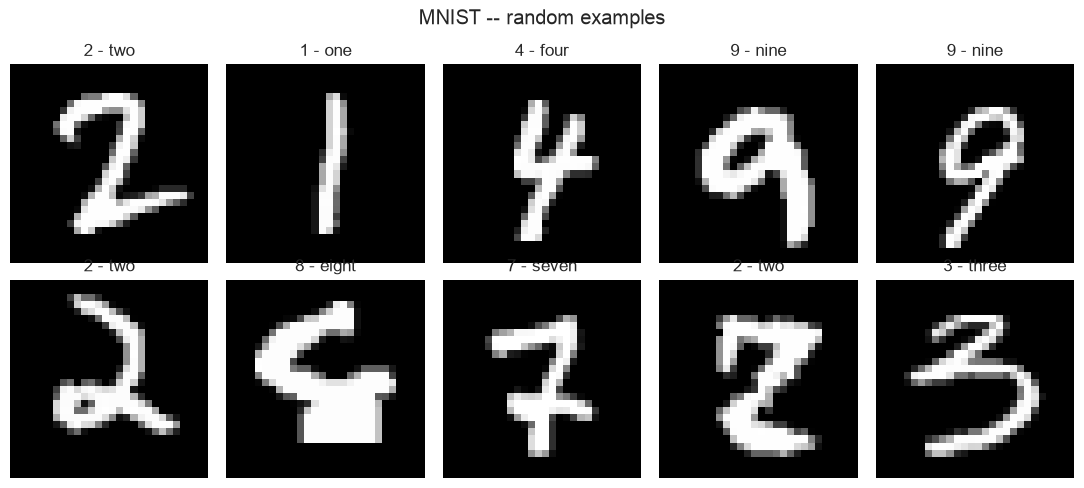

In [6]:
show_examples(mnist_X, mnist_y, mnist_train.classes, "MNIST -- random examples", "eda_mnist_examples.png")

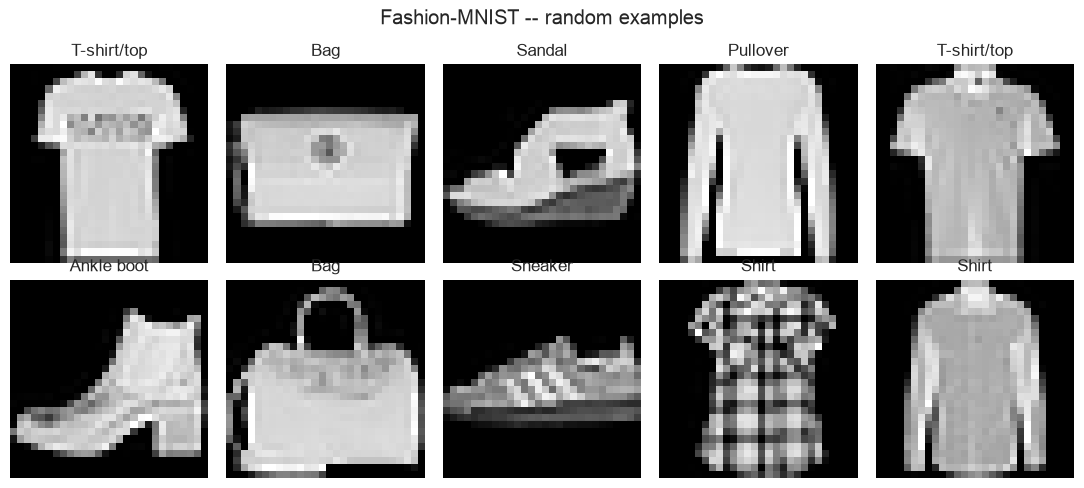

In [7]:
show_examples(fashion_X, fashion_y, fashion_train.classes, "Fashion-MNIST -- random examples", "eda_fashion_examples.png")


`MNIST` визуально проще: классы задаются формой цифры на черном фоне _(посмотрел состав корпуса -- выбросов каких-либо не увидел)_.

У `Fashion-MNIST` несколько классов реально похожи (`T-shirt/top`, `Shirt`, `Pullover`, `Coat`), так что ожидаю больше систематических ошибок именно между ними.


## Средний объект каждого класса


In [8]:
def plot_class_means(X, y, classes, title, filename):
    fig, axes = plt.subplots(2, 5, figsize=(11, 5))
    for cls, ax in enumerate(axes.ravel()):
        ax.imshow(X[y == cls].mean(axis=0), cmap="gray")
        ax.set_title(classes[cls])
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


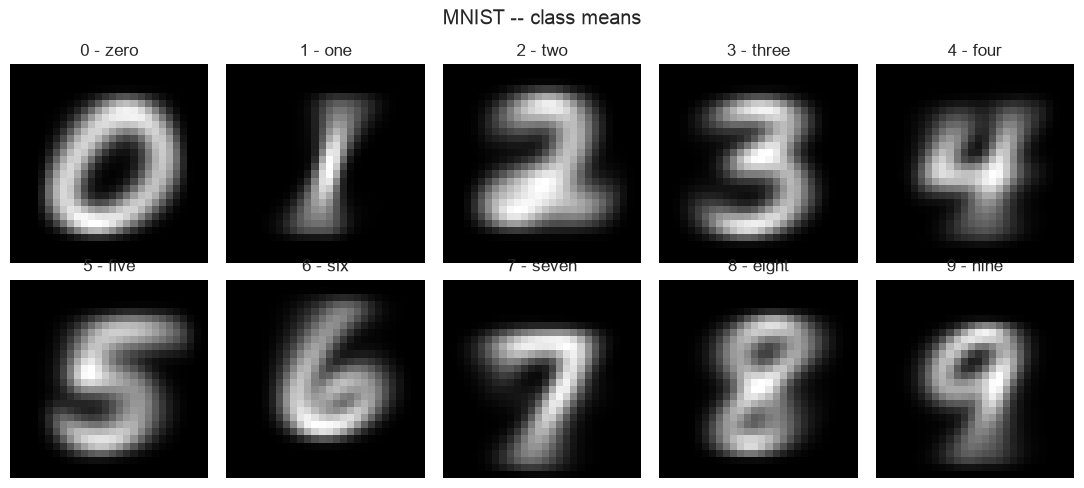

In [9]:
plot_class_means(mnist_X, mnist_y, mnist_train.classes, "MNIST -- class means", "eda_mnist_class_means.png")

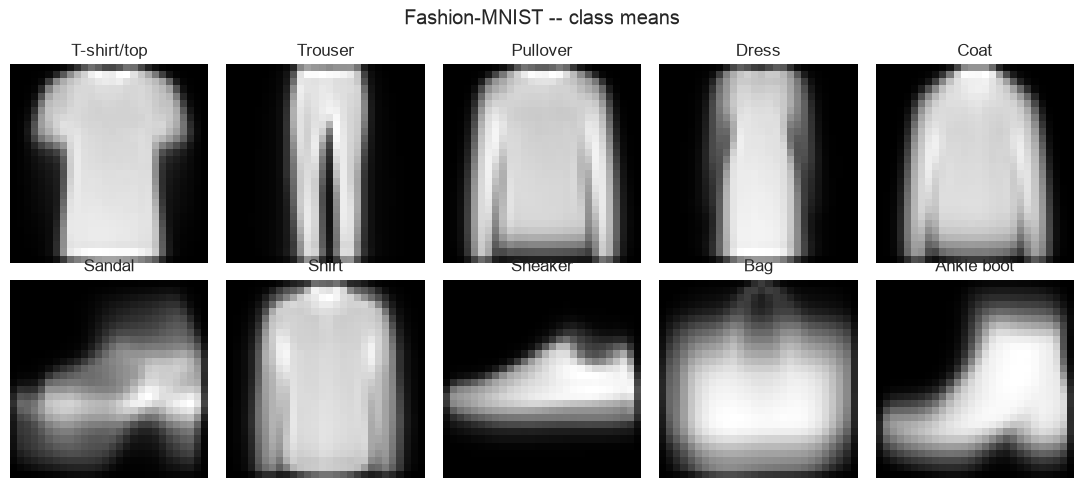

In [10]:
plot_class_means(fashion_X, fashion_y, fashion_train.classes, "Fashion-MNIST -- class means", "eda_fashion_class_means.png")


## Распределение интенсивности пикселей


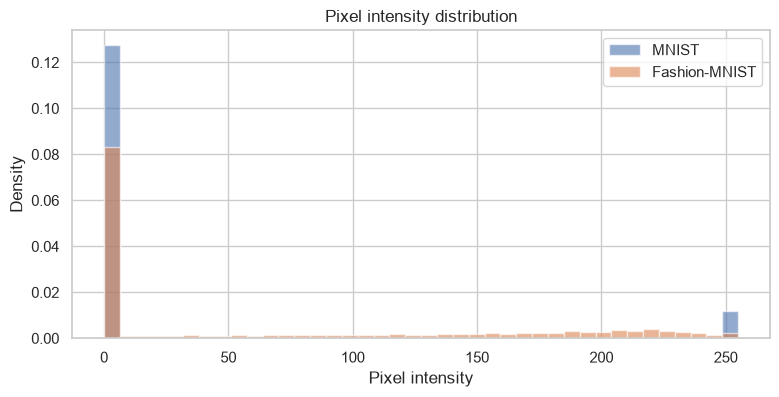

In [11]:
plt.figure(figsize=(9, 4))
plt.hist(mnist_X.ravel()[::50], bins=40, alpha=0.6, density=True, label="MNIST")
plt.hist(fashion_X.ravel()[::50], bins=40, alpha=0.6, density=True, label="Fashion-MNIST")
plt.xlabel("Pixel intensity")
plt.ylabel("Density")
plt.title("Pixel intensity distribution")
plt.legend()
plt.savefig(OUTPUT_DIR / "eda_pixel_hist.png", dpi=160, bbox_inches="tight")
plt.show()


У `MNIST` заметно больше фоновых нулей _(объясняется это тем, что само изображение -- меньше)_.   
`Fashion-MNIST` заполняет изображение плотнее, поэтому глобальные статистики изображения могут нести полезный сигнал для классических моделей.


## Feature engineering

Добавлю несколько дополнительных признаков, которые можно извлечь: `mean_brightness`, `pixel_std`, `ind_density`, `center_y`, `center_x`.

In [12]:
def engineered_features(X):
    X01 = X.astype(np.float32) / 255.0
    rows = np.arange(28, dtype=np.float32)[None, :, None]
    cols = np.arange(28, dtype=np.float32)[None, None, :]
    mass = X01.sum(axis=(1, 2)) + 1e-8

    return pd.DataFrame({
        "mean_brightness": X01.mean(axis=(1, 2)),
        "pixel_std": X01.std(axis=(1, 2)),
        "ink_density": (X01 > 0.2).mean(axis=(1, 2)),
        "center_y": (X01 * rows).sum(axis=(1, 2)) / mass / 27.0,
        "center_x": (X01 * cols).sum(axis=(1, 2)) / mass / 27.0,
    })

mnist_features = engineered_features(mnist_X)
fashion_features = engineered_features(fashion_X)
mnist_features.describe().T


,count,mean,std,min,25%,50%,75%,max
mean_brightness,60000.0,0.130660,0.043299,0.025440,0.099330,0.127386,0.157873,0.397574
pixel_std,60000.0,0.301312,0.047611,0.124900,0.268836,0.302826,0.334787,0.467293
ink_density,60000.0,0.161464,0.048299,0.034439,0.127551,0.159439,0.192602,0.433673
center_y,60000.0,0.518367,0.010711,0.499263,0.509072,0.518193,0.527630,0.537036
center_x,60000.0,0.518771,0.010774,0.499761,0.509400,0.518941,0.528129,0.537036


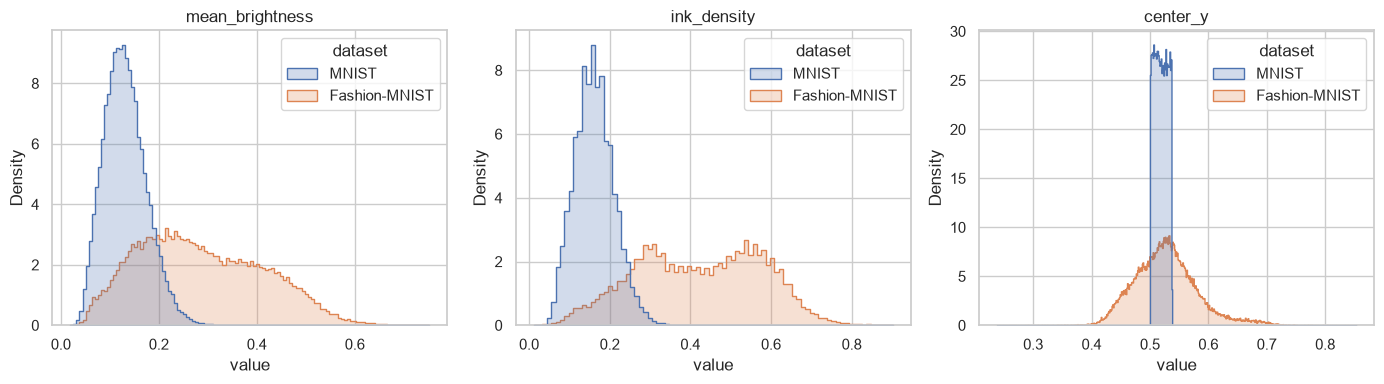

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feature in zip(axes, ["mean_brightness", "ink_density", "center_y"]):
    data = pd.DataFrame({
        "value": np.r_[mnist_features[feature], fashion_features[feature]],
        "dataset": ["MNIST"] * len(mnist_features) + ["Fashion-MNIST"] * len(fashion_features),
    })
    sns.histplot(data=data, x="value", hue="dataset", stat="density", common_norm=False, element="step", ax=ax)
    ax.set_title(feature)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_engineered_features.png", dpi=160, bbox_inches="tight")
plt.show()


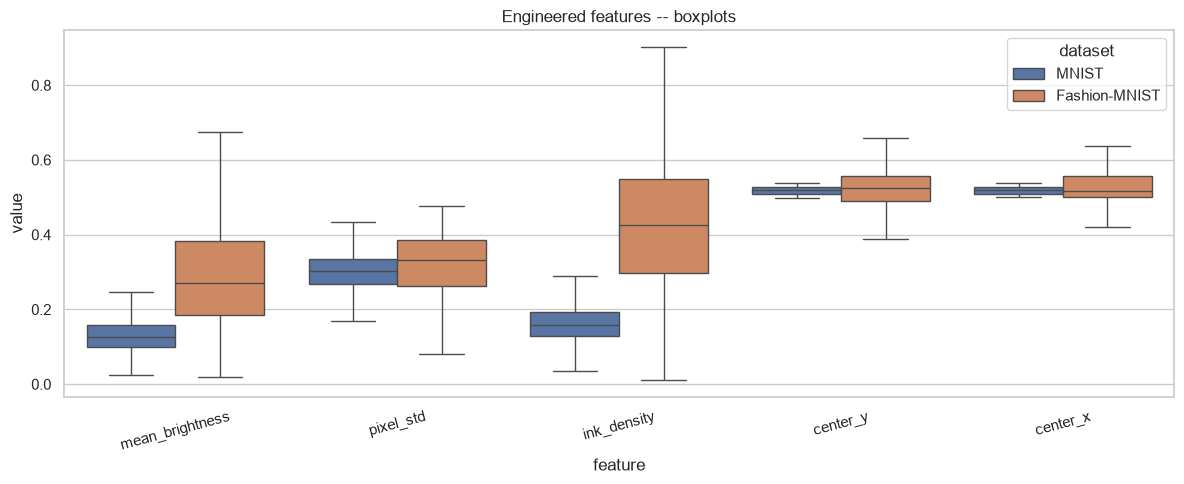

In [14]:
box_data = pd.concat([
    mnist_features.assign(dataset="MNIST"),
    fashion_features.assign(dataset="Fashion-MNIST"),
], ignore_index=True).melt(id_vars="dataset", var_name="feature", value_name="value")

plt.figure(figsize=(12, 5))
sns.boxplot(data=box_data, x="feature", y="value", hue="dataset", showfliers=False)
plt.title("Engineered features -- boxplots")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_engineered_features_boxplot.png", dpi=160, bbox_inches="tight")
plt.show()


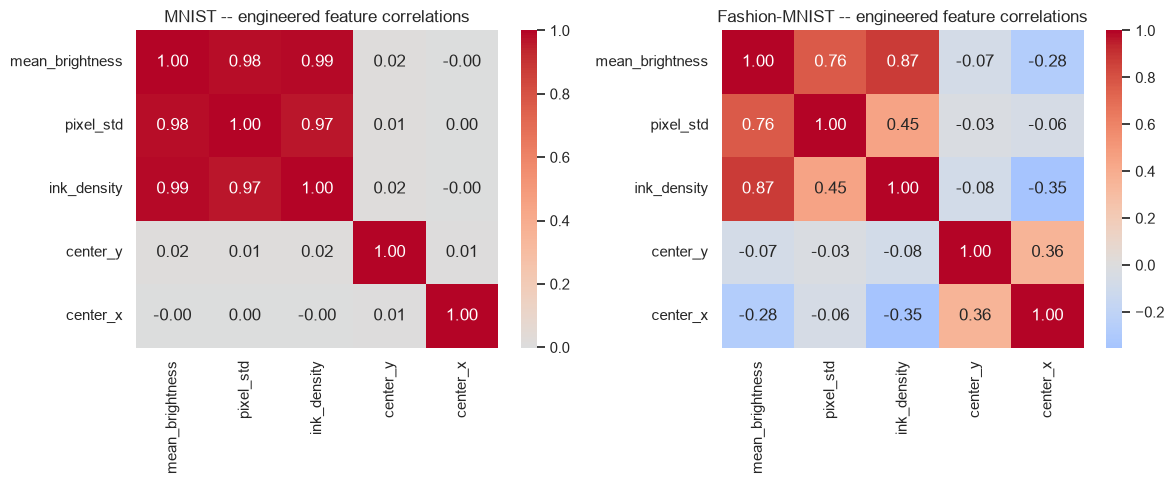

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, features, name in [
    (axes[0], mnist_features, "MNIST"),
    (axes[1], fashion_features, "Fashion-MNIST"),
]:
    sns.heatmap(features.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title(f"{name} -- engineered feature correlations")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_engineered_features_correlations.png", dpi=160, bbox_inches="tight")
plt.show()


Часть новых признаков оказались коррелированы _(в целом, понимая их физический смысл, резонно)_, буду это учитывать при скармливании моделям в будущем.

## Распределения новых признаков по классам

In [16]:
ENGINEERED_FEATURES = [
    "mean_brightness",
    "pixel_std",
    "ink_density",
    "center_y",
    "center_x",
]


def sample_features_by_class(features, y, classes, max_per_class=1500):
    parts = []

    for class_index, class_name in enumerate(classes):
        class_indices = np.flatnonzero(y == class_index)

        if len(class_indices) > max_per_class:
            class_indices = rng.choice(
                class_indices,
                size=max_per_class,
                replace=False,
            )

        part = features.iloc[class_indices].copy()
        part["class"] = str(class_name)
        parts.append(part)

    return pd.concat(parts, ignore_index=True)


def plot_features_by_class(features, y, classes, dataset_name, filename):
    plot_data = sample_features_by_class(features, y, classes)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for ax, feature in zip(axes, ENGINEERED_FEATURES):
        sns.violinplot(
            data=plot_data,
            x="class",
            y=feature,
            inner="quartile",
            cut=0,
            density_norm="width",
            ax=ax,
        )

        ax.set_title(feature)
        ax.set_xlabel("Class")
        ax.tick_params(axis="x", rotation=35)

    axes[-1].axis("off")

    fig.suptitle(
        f"{dataset_name} -- engineered feature distributions by class",
        fontsize=15,
    )
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / filename,
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

    stats = features.copy()
    stats["class"] = [classes[class_index] for class_index in y]

    return stats.groupby("class")[ENGINEERED_FEATURES].agg(["mean", "std"])

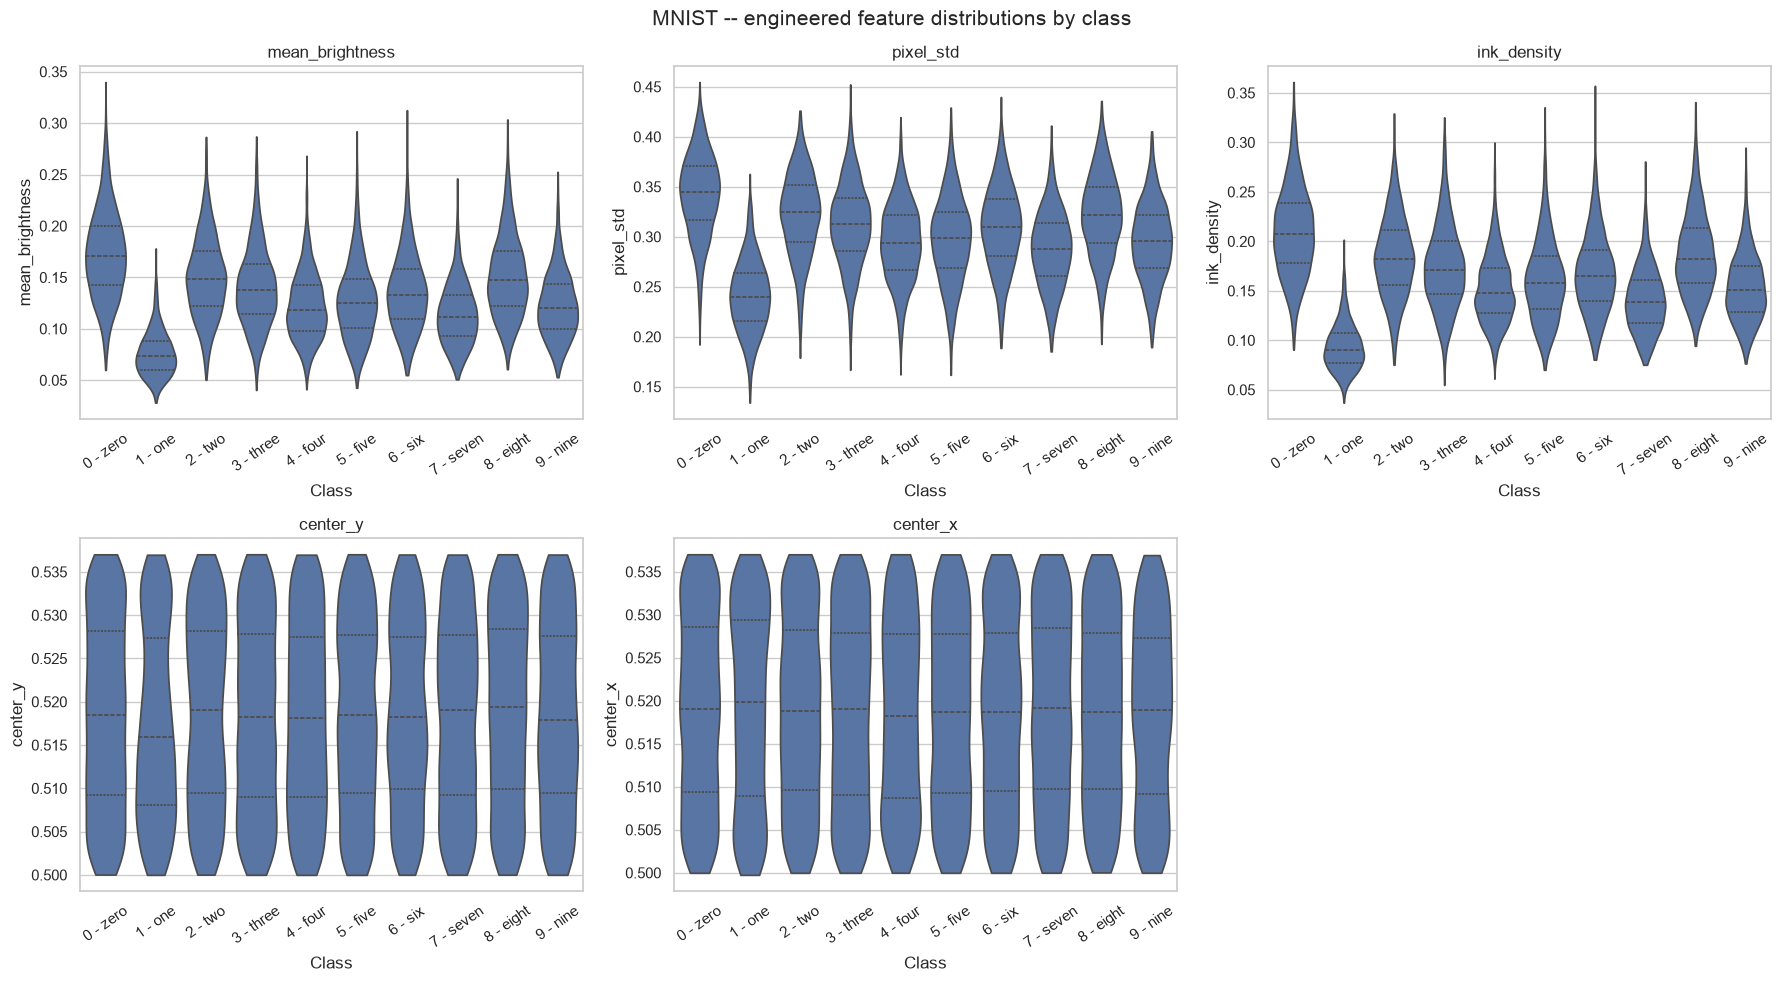

mean_brightness           pixel_std           ink_density            \
                     mean       std      mean       std        mean       std   
class                                                                           
0 - zero         0.173399  0.042106  0.342891  0.039508    0.210530  0.043366   
1 - one          0.075999  0.021993  0.240662  0.035663    0.093615  0.023707   
2 - two          0.148975  0.038054  0.321214  0.040003    0.183003  0.040329   
3 - three        0.141530  0.037791  0.313043  0.040605    0.175118  0.041009   
4 - four         0.121366  0.031889  0.293244  0.038576    0.151360  0.033847   
5 - five         0.128749  0.037267  0.298292  0.042419    0.161883  0.040750   
6 - six          0.137302  0.037432  0.309940  0.041195    0.168957  0.039744   
7 - seven        0.114528  0.030635  0.287557  0.038204    0.141563  0.032848   
8 - eight        0.150156  0.038636  0.320476  0.039963    0.185856  0.040403   
9 - nine         0.122590  0.032447  0.294356  0.038559    0.152915  0.034703   

           center_y            center_x            
               mean       std      mean       std  
class                                              
0 - zero   0.518559  0.010783  0.519025  0.010824  
1 - one    0.517135  0.010803  0.519301  0.011268  
2 - two    0.518723  0.010732  0.518470  0.010645  
3 - three  0.518316  0.010753  0.518849  0.010691  
4 - four   0.518528  0.010747  0.518662  0.010766  
5 - five   0.518550  0.010671  0.518662  0.010670  
6 - six    0.518514  0.010493  0.518546  0.010678  
7 - seven  0.518714  0.010701  0.518767  0.010768  
8 - eight  0.518504  0.010662  0.518825  0.010697  
9 - nine   0.518296  0.010653  0.518522  0.010623

In [17]:
mnist_feature_stats = plot_features_by_class(
    mnist_features,
    mnist_y,
    mnist_train.classes,
    "MNIST",
    "eda_mnist_engineered_features_by_class.png",
)

mnist_feature_stats

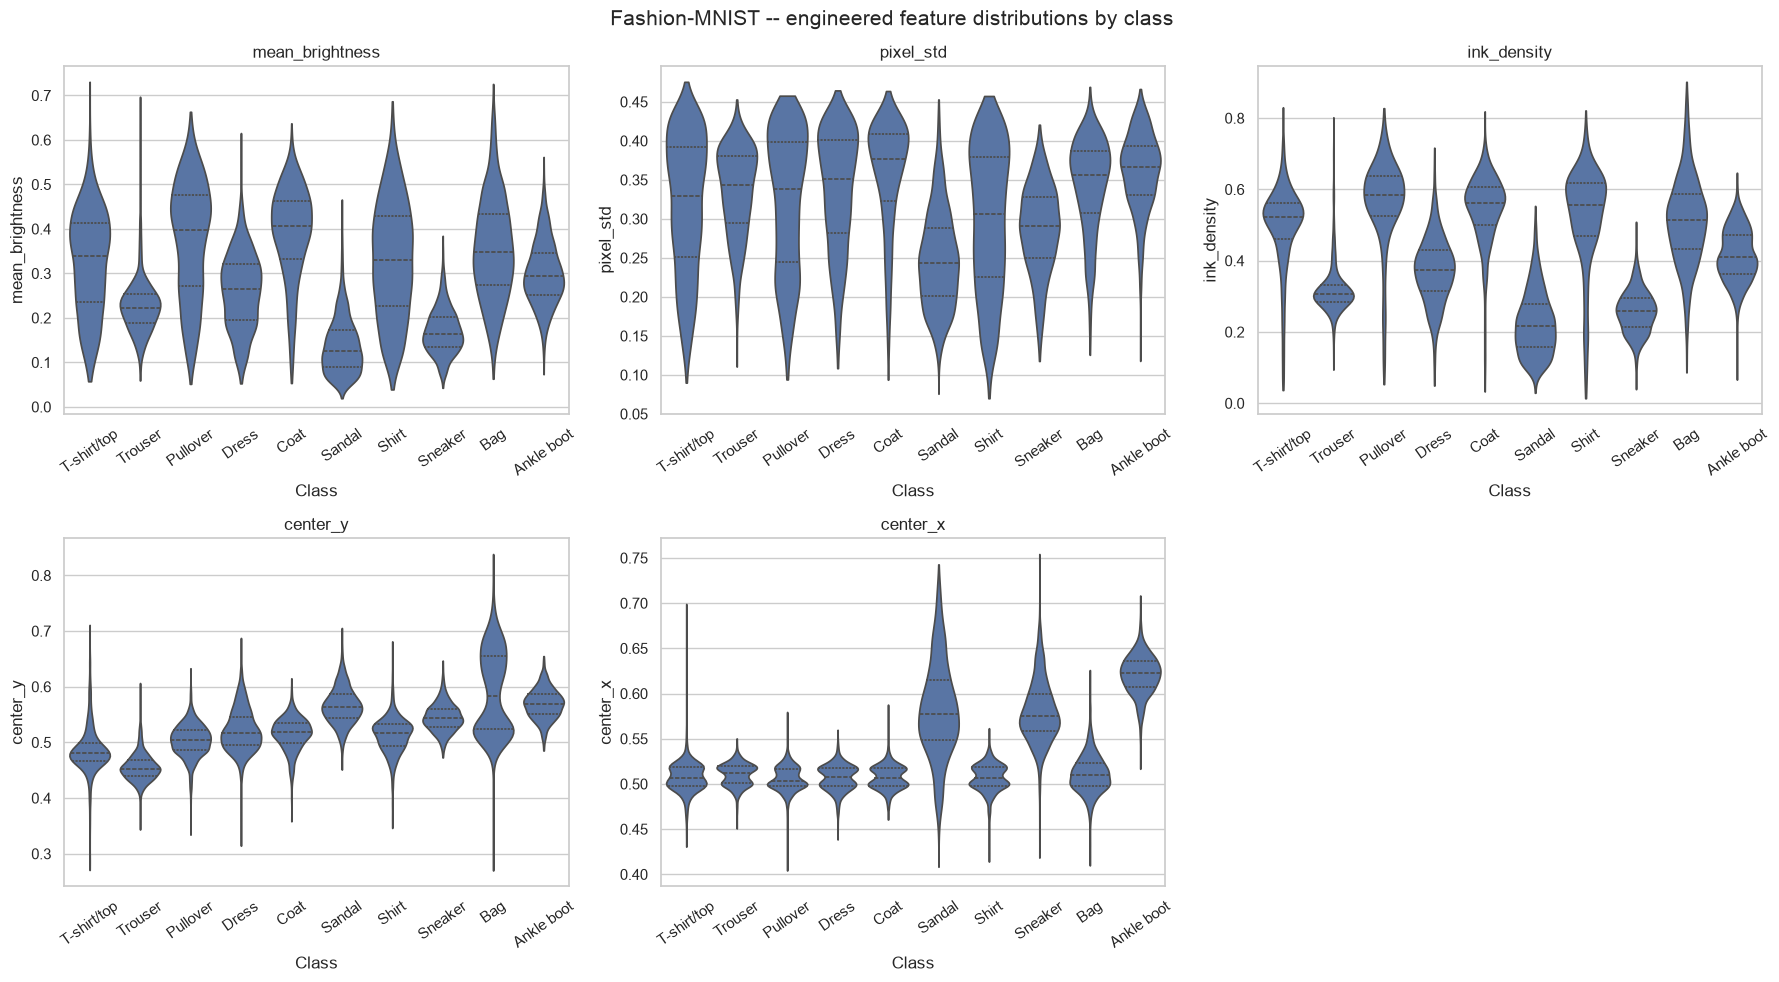

mean_brightness           pixel_std           ink_density  \
                       mean       std      mean       std        mean   
class                                                                   
Ankle boot         0.301197  0.071774  0.359983  0.050565    0.416740   
Bag                0.353557  0.112822  0.342063  0.060747    0.510875   
Coat               0.385326  0.103643  0.354637  0.071443    0.541180   
Dress              0.258898  0.083909  0.335880  0.074950    0.371535   
Pullover           0.376701  0.128042  0.323060  0.088841    0.564621   
Sandal             0.136735  0.062104  0.248102  0.061772    0.223914   
Shirt              0.331785  0.129743  0.299827  0.091568    0.524627   
Sneaker            0.167694  0.050343  0.284960  0.056244    0.254055   
T-shirt/top        0.325608  0.113384  0.320036  0.087990    0.494433   
Trouser            0.222905  0.056956  0.333942  0.057037    0.316056   

                       center_y            center_x            
                  std      mean       std      mean       std  
class                                                          
Ankle boot   0.071883  0.568820  0.027735  0.620790  0.021802  
Bag          0.122717  0.589592  0.075080  0.510957  0.021680  
Coat         0.097384  0.516084  0.029342  0.506739  0.012832  
Dress        0.090665  0.523309  0.040581  0.507058  0.014144  
Pullover     0.121656  0.503790  0.029072  0.505291  0.014270  
Sandal       0.086762  0.567482  0.033271  0.581236  0.052875  
Shirt        0.138345  0.512111  0.031582  0.506844  0.015224  
Sneaker      0.060992  0.544132  0.024839  0.580454  0.033216  
T-shirt/top  0.115522  0.484833  0.039851  0.507285  0.016655  
Trouser      0.063601  0.455792  0.026467  0.510628  0.011952

In [18]:
fashion_feature_stats = plot_features_by_class(
    fashion_features,
    fashion_y,
    fashion_train.classes,
    "Fashion-MNIST",
    "eda_fashion_engineered_features_by_class.png",
)

fashion_feature_stats

Видны некоторые корреляции между новыми признаками, и это нормально из-за их физического смысла _(см. ниже)_. Есть и некоррелирующие, мб моделям получится извлечь из них что-то полезное. В классическом ноутбуке добавляю их к 784 пикселям:

- `mean_brightness` -- общая заполненность изображения;
- `pixel_std` -- насколько контрастно распределены пиксели;
- `ink_density` -- доля заметно ненулевых пикселей;
- `center_x`, `center_y` -- центр массы изображения.

Для MLP их отдельно не добавляю: сеть и так получает все пиксели, а задача 24 должна в первую очередь измерять эффект архитектуры.

**Какого-то явного признака-разделителя не найдено :(**

## Где в изображении находится сигнал


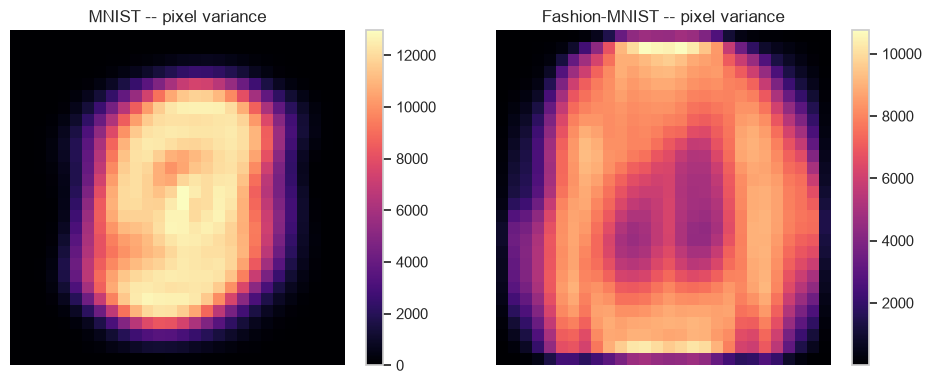

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, X, name in [(axes[0], mnist_X, "MNIST"), (axes[1], fashion_X, "Fashion-MNIST")]:
    variance_map = X.astype(np.float32).var(axis=0)
    im = ax.imshow(variance_map, cmap="magma")
    ax.set_title(f"{name} -- pixel variance")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_pixel_variance.png", dpi=160, bbox_inches="tight")
plt.show()


В обоих датасетах информативна в основном центральная область. Крайние пиксели вручную не выкидываю: тогда мы бы уже меняли представление и смешивали эффект feature selection с эффектом depth/width.


## Похожесть классов по средним изображениям


In [20]:
def centroid_distance_plot(X, y, classes, title, filename):
    centroids = np.stack([X[y == cls].mean(axis=0).ravel() for cls in range(10)])
    distances = pairwise_distances(centroids)
    plt.figure(figsize=(9, 7))
    sns.heatmap(distances, xticklabels=classes, yticklabels=classes, cmap="viridis")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()


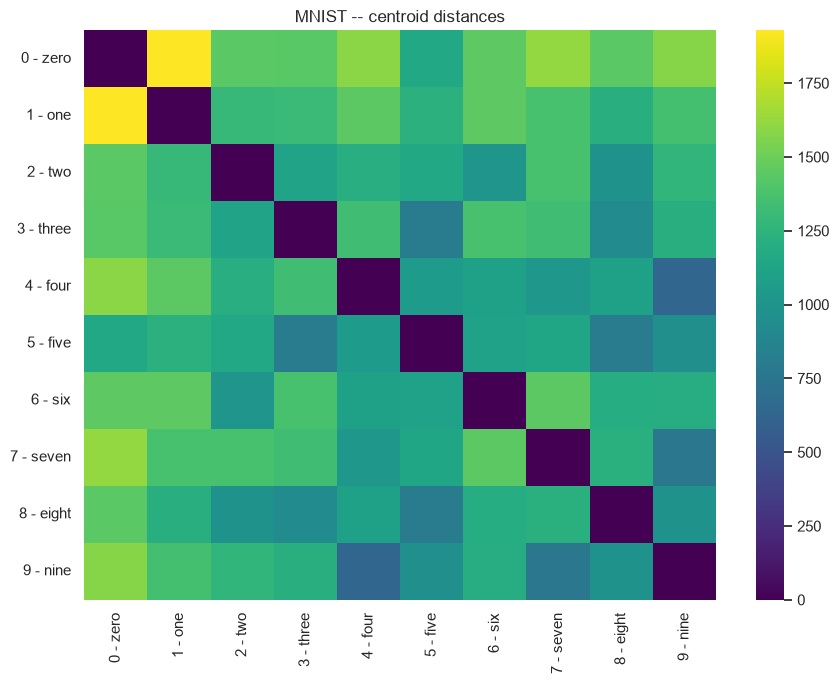

In [21]:
centroid_distance_plot(mnist_X, mnist_y, mnist_train.classes, "MNIST -- centroid distances", "eda_mnist_centroid_distances.png")

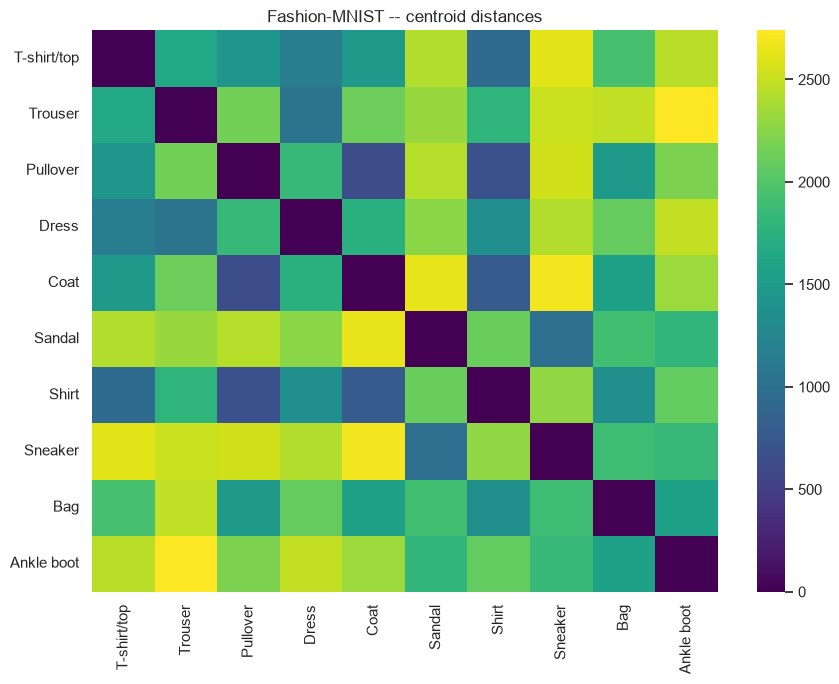

In [22]:
centroid_distance_plot(fashion_X, fashion_y, fashion_train.classes, "Fashion-MNIST -- centroid distances", "eda_fashion_centroid_distances.png")


Опять же, в `Fashion`-корпусе есть довольно схожие между собой классы, в то время как у чисел такая зависимость менее выражена.

## PCA-проекция


In [23]:
def plot_pca(X, y, title, filename):
    sample_idx = rng.choice(len(X), 5000, replace=False)
    X_sample = X[sample_idx].reshape(len(sample_idx), -1).astype(np.float32) / 255.0
    y_sample = y[sample_idx]
    projection = PCA(n_components=2, random_state=SEED).fit_transform(X_sample)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(projection[:, 0], projection[:, 1], c=y_sample, s=5, alpha=0.5, cmap="tab10")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter, ticks=range(10))
    plt.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()



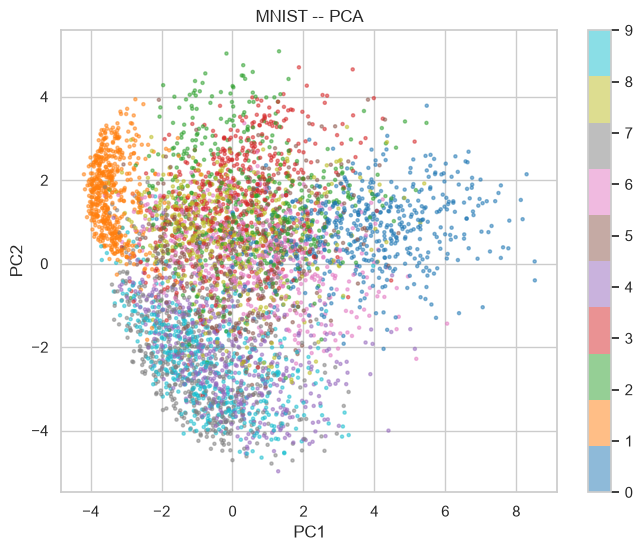

In [24]:
plot_pca(mnist_X, mnist_y, "MNIST -- PCA", "eda_mnist_pca.png")

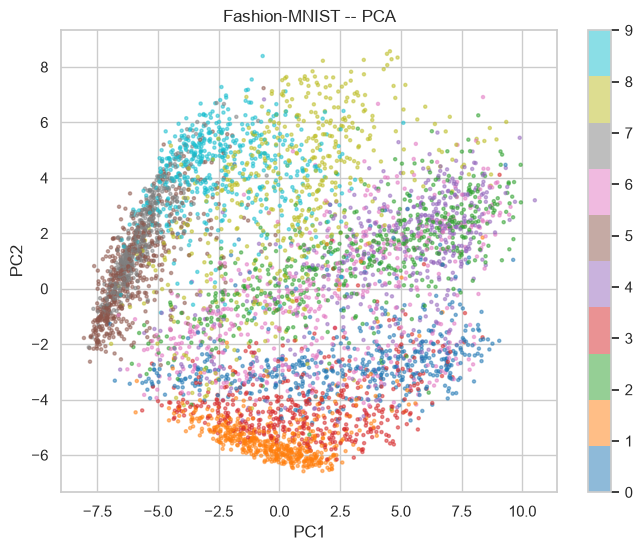

In [25]:
plot_pca(fashion_X, fashion_y, "Fashion-MNIST -- PCA", "eda_fashion_pca.png")


`Fashion` чуть более разделим, хотя все равно не панацея.

## Выводы

- `MNIST` и `Fashion-MNIST` имеют одинаковый размер входа и число классов -- хороший контролируемый набор для исследования архитектуры, выбор корпусов одобряю.
- Основная метрика дальше -- `balanced accuracy`; дополнительно `macro-F1`, `macro-precision`, `macro-recall`.
- Пропусков и категориальных признаков нет.
- По средним образам и PCA видно, что главная зона риска `Fashion-MNIST` -- похожие виды верхней одежды. Это потом отдельно проверю по confusion matrix.
